In [336]:
%pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [337]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, pi

In [338]:
def magnetic_field(I, xi, yi, zi, x, y, z):
    """
    Calcula el campo magnético en el punto (x, y, z) provocado por un conductor formado por los puntos (xi, yi, zi) que transporta una corriente I.
    """
    Bx = np.zeros_like(x, dtype=float)
    By = np.zeros_like(y, dtype=float)
    Bz = np.zeros_like(z, dtype=float)

    for i in range(len(xi) - 1):
        dlx = xi[i + 1] - xi[i]
        dly = yi[i + 1] - yi[i]
        dlz = zi[i + 1] - zi[i]
        
        rx = x - (xi[i] + xi[i + 1]) / 2
        ry = y - (yi[i] + yi[i + 1]) / 2
        rz = z - (zi[i] + zi[i + 1]) / 2
        
        r_mag = np.sqrt(rx**2 + ry**2 + rz**2)

        denom = np.where(r_mag == 0, np.inf, r_mag**3)
        factor = (mu_0 * I) / (4 * pi * denom)

        dBx = (dly * rz - dlz * ry) * factor
        dBy = (dlz * rx - dlx * rz) * factor
        dBz = (dlx * ry - dly * rx) * factor

        Bx += dBx
        By += dBy
        Bz += dBz
    
    return Bx, By, Bz

In [339]:
lim = 3.0
def plot_3d(title, X, Y, Z, Bx, By, Bz):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.quiver(X, Y, Z, Bx, By, Bz, length=.4, linewidth=0.6, color='C0', normalize=True)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('z [m]')
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    plt.title(title)
    plt.show()

def plot_2d(title, labelx, labely, X, Y, Bx, By, markers, Bz = None):
    plt.figure(figsize=(8, 8))

    if Bz is None:
        plt.quiver(X, Y, Bx, By, pivot='mid')
    else:
        positive = Bz > 0
        negative = Bz < 0
        plt.quiver(X[positive], Y[positive], Bx[positive], By[positive], color='blue', pivot='mid', label='Saliente')
        plt.quiver(X[negative], Y[negative], Bx[negative], By[negative], color='red', pivot='mid', label='Entrante')

    for item in markers:
        x, y, marker = item
        label = f'Alambre con corriente {"saliente" if marker == "o" else "entrante"}'
        color = 'green' if marker == 'o' else 'orange'
        plt.scatter([x], [y], marker=marker, color=color, label=label)

    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.axis('equal')
    plt.title(title)
    plt.legend()
    plt.show()

In [340]:
# Primer conductor: alambre recto de (0, 0, -1) a (0, 0, 1) con corriente I1 = 1.0 A
I1 = 10.0
x1 = np.zeros(2000)
y1 = np.zeros(2000)
z1 = np.linspace(-1, 1, 2000)

# Segundo conductor: espira de radio a = 1.0 m en el plano xy con corriente I2 = 2.0 A
I2 = 2.0
a = 1.0
theta = np.linspace(0, 2 * np.pi, 2000) # Sentido antihorario
x2 = a * np.cos(theta)
y2 = a * np.sin(theta)
z2 = np.zeros_like(theta)

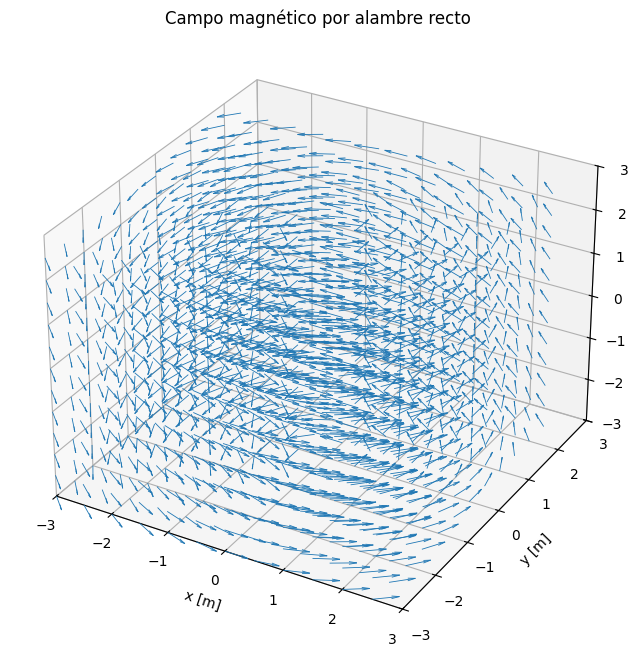

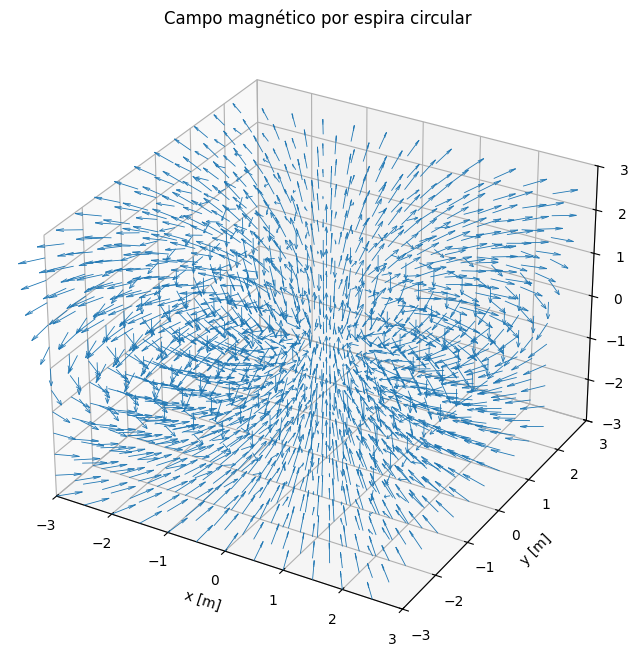

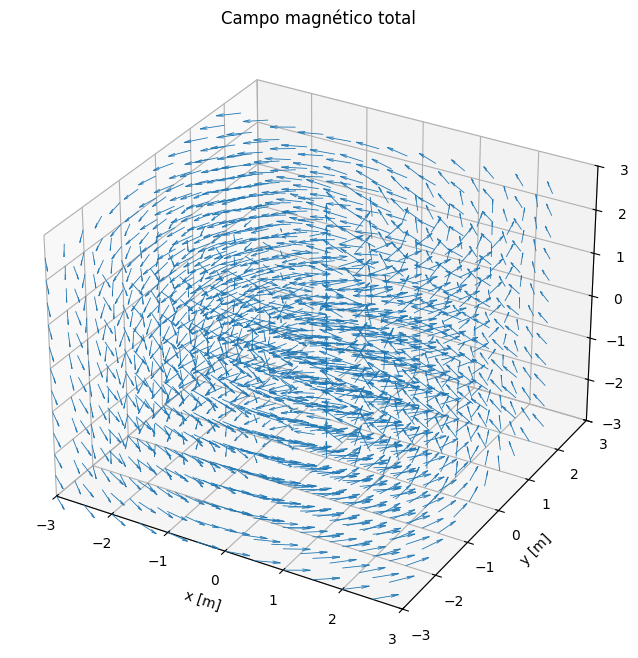

In [341]:
x = np.linspace(-3, 3, 12, endpoint=False)
y = np.linspace(-3, 3, 12, endpoint=False)
z = np.linspace(-3, 3, 12, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z)

Bx1, By1, Bz1 = magnetic_field(I1, x1, y1, z1, X, Y, Z)
plot_3d('Campo magnético por alambre recto', X, Y, Z, Bx1, By1, Bz1)

Bx2, By2, Bz2 = magnetic_field(I2, x2, y2, z2, X, Y, Z)
plot_3d('Campo magnético por espira circular', X, Y, Z, Bx2, By2, Bz2)
    
Bx, By, Bz = Bx1 + Bx2, By1 + By2, Bz1 + Bz2
plot_3d('Campo magnético total', X, Y, Z, Bx, By, Bz)

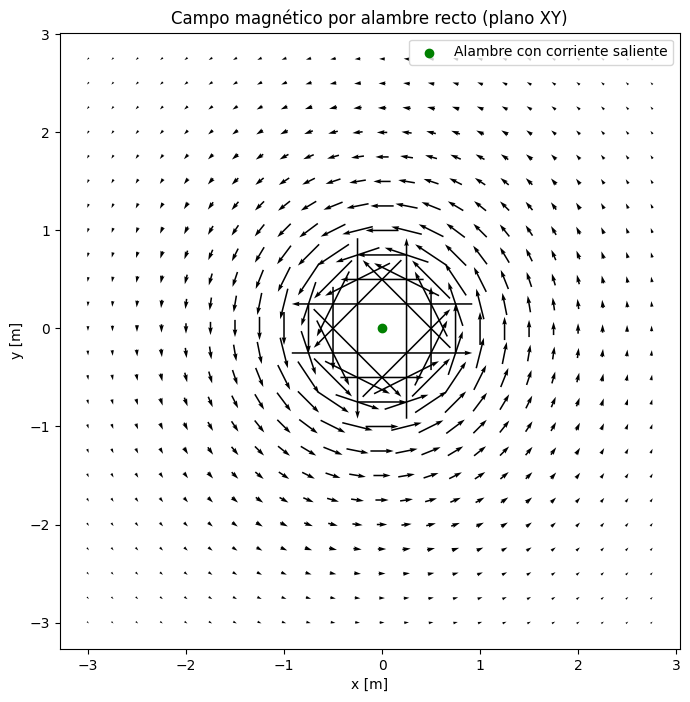

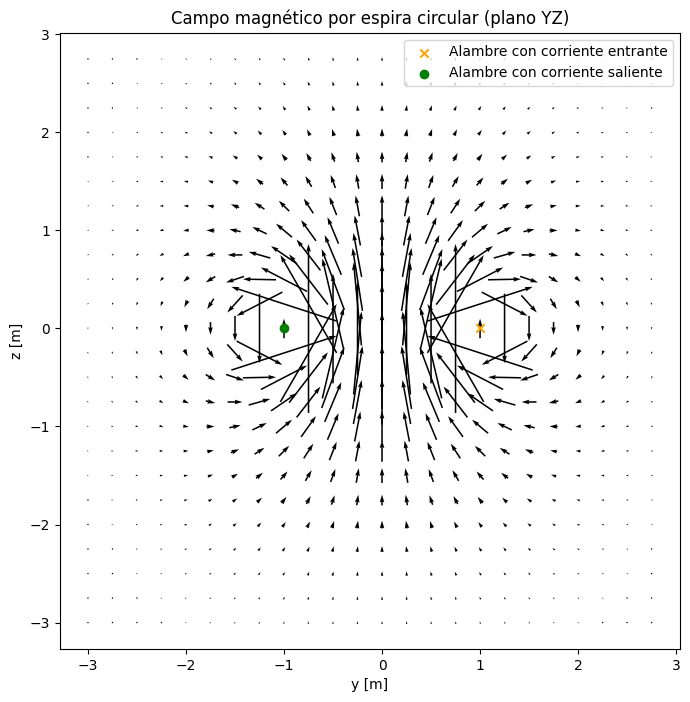

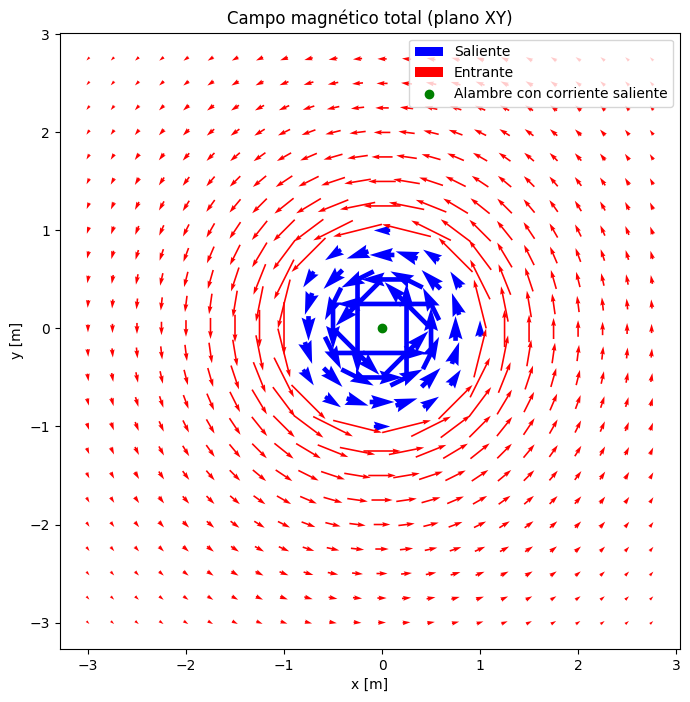

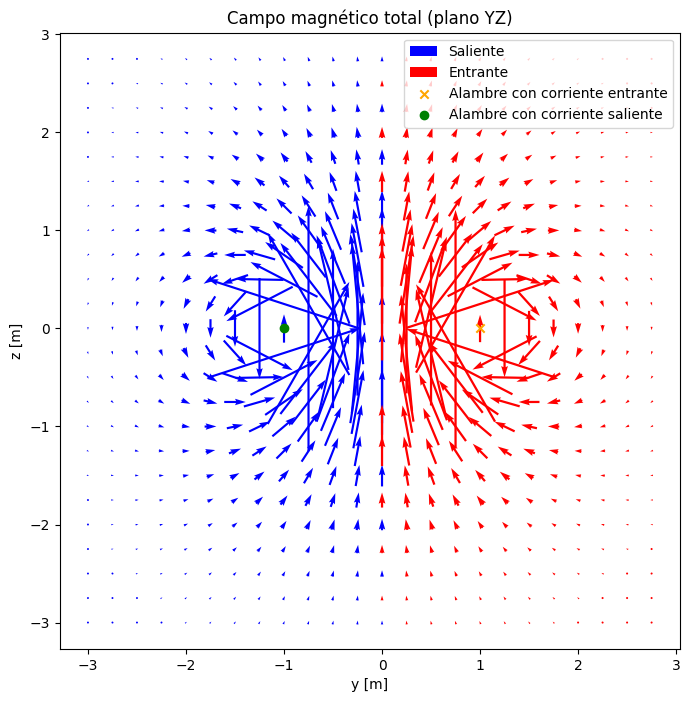

In [350]:
x = np.linspace(-lim, lim, 24, endpoint=False)
y = np.linspace(-lim, lim, 24, endpoint=False)
z = np.linspace(-lim, lim, 24, endpoint=False)


X_xy, Y_xy = np.meshgrid(x, y)
Z_xy = np.zeros_like(X_xy)

Bxy_x1, Bxy_y1, Bxy_z1 = magnetic_field(I1, x1, y1, z1, X_xy, Y_xy, Z_xy)
Bxy_x2, Bxy_y2, Bxy_z2 = magnetic_field(I2, x2, y2, z2, X_xy, Y_xy, Z_xy)

plot_2d('Campo magnético por alambre recto (plano XY)', 'x [m]', 'y [m]', X_xy, Y_xy, Bxy_x1, Bxy_y1, [ (0,0,'o') ])


Y_yz, Z_yz = np.meshgrid(y, z)
X_yz = np.zeros_like(Y_yz)
Byz_x1, Byz_y1, Byz_z1 = magnetic_field(I1, x1, y1, z1, X_yz, Y_yz, Z_yz)
Byz_x2, Byz_y2, Byz_z2 = magnetic_field(I2, x2, y2, z2, X_yz, Y_yz, Z_yz)

plot_2d('Campo magnético por espira circular (plano YZ)', 'y [m]', 'z [m]', Y_yz, Z_yz, Byz_y2, Byz_z2, [ (a,0,'x'), (-a,0,'o') ])


BXYx, BXYy, BXYz = Bxy_x1 + Bxy_x2, Bxy_y1 + Bxy_y2, Bxy_z1 + Bxy_z2
BYZx, BYZy, BYZz = Byz_x1 + Byz_x2, Byz_y1 + Byz_y2, Byz_z1 + Byz_z2

plot_2d('Campo magnético total (plano XY)', 'x [m]', 'y [m]', X_xy, Y_xy, BXYx, BXYy, [ (0,0,'o') ], BXYz)
plot_2d('Campo magnético total (plano YZ)', 'y [m]', 'z [m]', Y_yz, Z_yz, BYZy, BYZz, [ (a,0,'x'), (-a,0,'o') ], BYZx)

In [343]:
# Bobinas de Helmholtz
Rh = 1.0  # Radio de las bobinas y distancia entre ellas
Ih = 1.0
theta = np.linspace(0, 2 * np.pi, 2000) # Sentido antihorario
x_h1 = Rh * np.cos(theta)
y_h1 = Rh * np.sin(theta)
z_h1 = np.full_like(theta, -Rh/2)
x_h2 = Rh * np.cos(theta)
y_h2 = Rh * np.sin(theta)
z_h2 = np.full_like(theta, Rh/2)

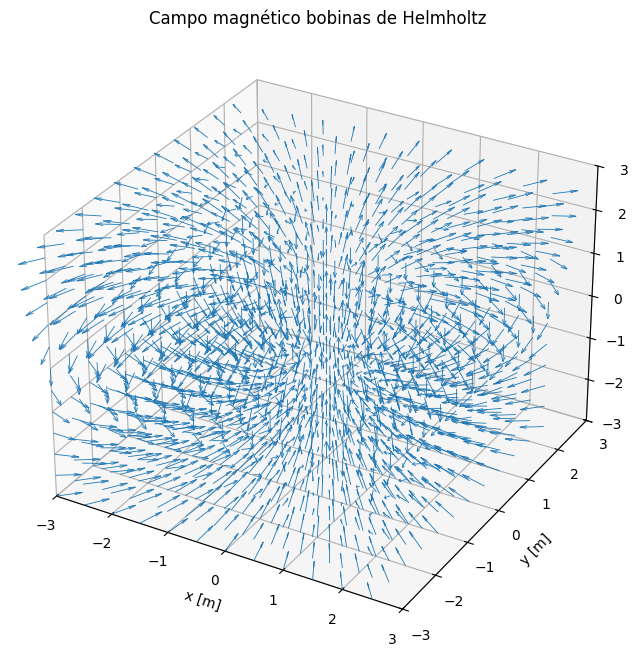

In [344]:
x = np.linspace(-3, 3, 12, endpoint=False)
y = np.linspace(-3, 3, 12, endpoint=False)
z = np.linspace(-3, 3, 12, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z)

Bh_x1, Bh_y1, Bh_z1 = magnetic_field(Ih, x_h1, y_h1, z_h1, X, Y, Z)
Bh_x2, Bh_y2, Bh_z2 = magnetic_field(Ih, x_h2, y_h2, z_h2, X, Y, Z)
Bh_x, Bh_y, Bh_z = Bh_x1 + Bh_x2, Bh_y1 + Bh_y2, Bh_z1 + Bh_z2

plot_3d('Campo magnético bobinas de Helmholtz', X, Y, Z, Bh_x, Bh_y, Bh_z)

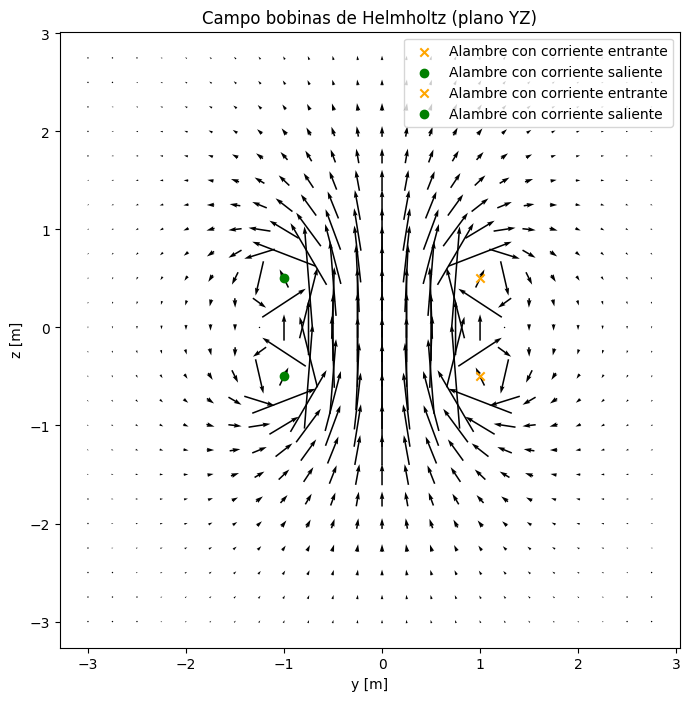

In [345]:
x = np.linspace(-lim, lim, 24, endpoint=False)
y = np.linspace(-lim, lim, 24, endpoint=False)
z = np.linspace(-lim, lim, 24, endpoint=False)

Y_yz, Z_yz = np.meshgrid(y, z)
X_yz = np.zeros_like(Y_yz)

Bhyz_x1, Bhyz_y1, Bhyz_z1 = magnetic_field(Ih, x_h1, y_h1, z_h1, X_yz, Y_yz, Z_yz)
Bhyz_x2, Bhyz_y2, Bhyz_z2 = magnetic_field(Ih, x_h2, y_h2, z_h2, X_yz, Y_yz, Z_yz)
BhYZ_x, BhYZ_y, BhYZ_z = Bhyz_x1 + Bhyz_x2, Bhyz_y1 + Bhyz_y2, Bhyz_z1 + Bhyz_z2

plot_2d('Campo bobinas de Helmholtz (plano YZ)', 'y [m]', 'z [m]', Y_yz, Z_yz, BhYZ_y, BhYZ_z, [ (Rh,Rh/2,'x'), (-Rh,Rh/2,'o'), (Rh,-Rh/2,'x'), (-Rh,-Rh/2,'o') ])

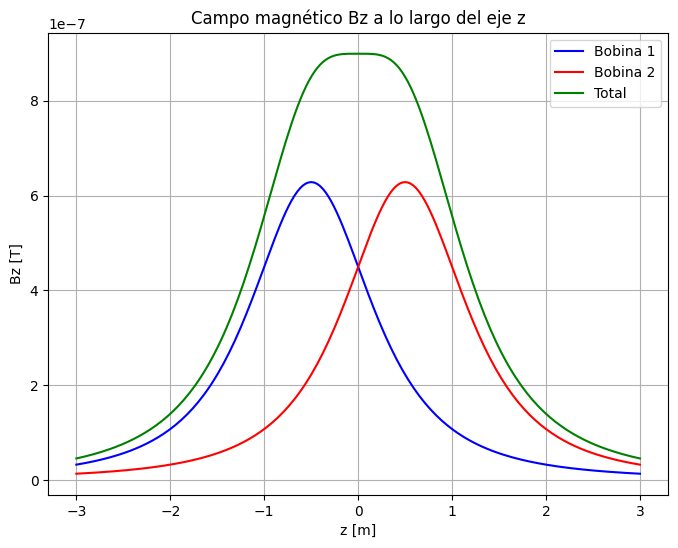

In [353]:
# Graficar Bz vs z para cada bobina y la suma
z = np.linspace(-lim, lim, 200)
x = np.zeros_like(z)
y = np.zeros_like(z)

Bh1_x, Bh1_y, Bh1_z = magnetic_field(Ih, x_h1, y_h1, z_h1, x, y, z)
Bh2_x, Bh2_y, Bh2_z = magnetic_field(Ih, x_h2, y_h2, z_h2, x, y, z)
Bh_total_z = Bh1_z + Bh2_z

plt.figure(figsize=(8,6))
plt.plot(z, Bh1_z, label='Bobina 1', color='blue')
plt.plot(z, Bh2_z, label='Bobina 2', color='red')
plt.plot(z, Bh_total_z, label='Total', color='green')
plt.xlabel('z [m]')
plt.ylabel('Bz [T]')
plt.title('Campo magnético Bz a lo largo del eje z')
plt.legend()
plt.grid(True)
plt.show()